# Train model for PV generation

* load pv data separately from database
* train test split
* train and evaluate base models 
    - Linear Regression
    - Random Forest
    - LightGBM
    - XGBoost

In [3]:
# Set a consistent style for all plots
import matplotlib.pyplot as plt
plt.rcParams.update({
    'axes.grid':      True,
    'grid.color':     '#DCDCDC',
    'grid.linewidth': 0.5,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'axes.facecolor': 'white',
    'font.family':    'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titlepad':  13,
    'axes.labelsize': 10,
    'axes.labelpad':  8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'legend.frameon':    True,
    'legend.facecolor':  'white',
    'legend.edgecolor':  '#DCDCDC',
    'legend.framealpha': 1.0,
    'legend.fontsize':   9,
})

import sys
import os

# Add the src directory to the system path to allow importing custom modules
project_root = os.path.abspath("..")
src_dir = os.path.join(project_root, "src")
util_dir = os.path.join(project_root, "util")

if project_root not in sys.path:
    sys.path.insert(0, project_root)
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)
if util_dir not in sys.path:
    sys.path.insert(0, util_dir)


import warnings
warnings.filterwarnings('ignore')

# Enable autoreload to automatically reload modules when they are edited
%load_ext autoreload
%autoreload 2
    
from src.config import *
from util.weather_weighted import *
from src.etl_price import *
from src.fetch_price_data import *
from src.train_predict_model import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
df = load_time_series_data_from_db()

print(df.info())
display(df.describe())
display(df.head())


<class 'pandas.DataFrame'>
DatetimeIndex: 65039 entries, 2018-12-31 23:00:00+00:00 to 2026-06-02 21:00:00+00:00
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   gen_other_conventional_mwh        65024 non-null  float64
 1   gen_pv_mwh                        65024 non-null  float64
 2   gen_wind_offshore_mwh             65024 non-null  float64
 3   gen_wind_onshore_mwh              65024 non-null  float64
 4   price_de_lu_eur_mwh               65039 non-null  float64
 5   pv_weather_cloud_cover            65015 non-null  float64
 6   pv_weather_diffuse_radiation      65015 non-null  float64
 7   pv_weather_direct_radiation       65015 non-null  float64
 8   pv_weather_shortwave_radiation    65015 non-null  float64
 9   wind_weather_wind_direction_100m  65015 non-null  float64
 10  wind_weather_wind_speed_100m      65015 non-null  float64
dtypes: float64(11)
memory usage: 6.

series_id,gen_other_conventional_mwh,gen_pv_mwh,gen_wind_offshore_mwh,gen_wind_onshore_mwh,price_de_lu_eur_mwh,pv_weather_cloud_cover,pv_weather_diffuse_radiation,pv_weather_direct_radiation,pv_weather_shortwave_radiation,wind_weather_wind_direction_100m,wind_weather_wind_speed_100m
count,65024.000000,65024.000000,65024.000000,65024.000000,65039.000000,65015.000000,65015.000000,65015.000000,65015.000000,65015.000000,65015.000000
mean,1594.258124,6375.471882,2899.310415,11970.254734,94.875773,65.919523,54.011497,81.441159,135.452657,204.529072,30.955857
std,266.788483,10006.308107,1968.126557,9470.199583,92.079727,27.866587,71.891255,140.797017,200.179885,75.771573,12.996186
min,530.750000,0.000000,0.000000,46.500000,-500.000000,0.000000,0.000000,0.000000,0.000000,8.285717,3.491786
25%,1415.750000,3.000000,1108.500000,4524.250000,38.250000,46.347463,0.000000,0.000000,0.000000,145.067606,21.254516
50%,1577.500000,190.750000,2684.875000,9257.500000,76.960000,71.719075,5.671566,0.945914,7.179378,218.231014,29.197578
75%,1789.250000,9940.375000,4585.812500,17179.437500,116.505000,90.196562,98.076208,107.262088,220.825230,263.331935,38.661687
max,2669.500000,56071.650000,8448.340000,48499.500000,936.280000,100.000000,344.501295,766.031637,886.747525,355.010877,104.787703


series_id,gen_other_conventional_mwh,gen_pv_mwh,gen_wind_offshore_mwh,gen_wind_onshore_mwh,price_de_lu_eur_mwh,pv_weather_cloud_cover,pv_weather_diffuse_radiation,pv_weather_direct_radiation,pv_weather_shortwave_radiation,wind_weather_wind_direction_100m,wind_weather_wind_speed_100m
time,,,,,,,,,,,
2018-12-31 23:00:00+00:00,1724.25,0.0,3134.00,20314.25,28.32,95.228754,0.0,0.0,0.0,257.697773,53.486212
2019-01-01 00:00:00+00:00,1682.25,0.0,2868.25,22297.25,10.07,93.784571,0.0,0.0,0.0,255.540277,58.021481
2019-01-01 01:00:00+00:00,1625.25,0.0,2460.25,23168.50,-4.08,99.448610,0.0,0.0,0.0,259.660683,59.465160
2019-01-01 02:00:00+00:00,1615.25,0.0,2696.50,24471.75,-9.91,100.000000,0.0,0.0,0.0,264.739757,60.351696
2019-01-01 03:00:00+00:00,1621.50,0.0,2578.00,26320.50,-7.41,98.505048,0.0,0.0,0.0,269.234658,61.293313


## Train model for PV generation

* prepare data
    - add time features: year, hour, month
    - add lag and rolling windows
* train test split
* train and evaluate base model
    - Linear Regression
    - Random Forest
    - LightGBM
    - XGBoost

In [ ]:
# Keep time as a normal column for train_test_split_by_date
from util.time_features import TimeFeatureCreator
from src.config import DE_STATE_CODES, PANDEMIC_START, PANDEMIC_END
import pandas as pd 

# prepare features for PV generation model from dataframe loaded from time series table in database, which will be used as input for the price model
def prepare_historical_pv_features(df):
    cols_pv_features = ['gen_pv_mwh', 
                        'pv_weather_cloud_cover',
                        'pv_weather_diffuse_radiation',
                        'pv_weather_direct_radiation',
                        'pv_weather_shortwave_radiation']

    df_pv = df[cols_pv_features].copy().reset_index()

    # Create lag and rolling features for the weather variables, defaults to lags of 24 and 168 hours and rolling windows of 24 and 168 hours
    df_pv = create_lag_rolling_features(df_pv, cols_pv_features)

    # Create time features
    tfc = TimeFeatureCreator(
        country="DE",
        state_codes=DE_STATE_CODES,
        pandemic_start=PANDEMIC_START,
        pandemic_end=PANDEMIC_END,
        time_column="time",
        include_features=["year", "hour", "month"],  # add more if needed
    )

    df_pv = tfc.create(df_pv, year=int(df_pv["time"].dt.year.max()))
    df_pv = df_pv.dropna().reset_index(drop=True)

    return df_pv

# train test split
train_end_date = pd.Timestamp("2025-10-01", tz="UTC")
df_pv = prepare_historical_pv_features(df)
pv_features_train, pv_target_train, pv_features_test, pv_target_test = train_test_split_by_date(
    df_pv, 'time', 'gen_pv_mwh', train_end_date
)

print(pv_features_train.shape)
print(pv_target_train.shape)
print(pv_features_test.shape)
print(pv_target_test.shape)

(58993, 23)
(58993,)
(5854, 23)
(5854,)


In [ ]:
# train a linear regression model
from sklearn.linear_model import LinearRegression
model_lin = LinearRegression()
pipeline_lin = init_model_pipeline(pv_features_train, model_lin)
pred_lin = train_model_predict(pipeline_lin, pv_features_train, pv_target_train, pv_features_test)
print_scores('Linear Regression', pv_target_test, pred_lin)

-------------------- scoring --------------------
model                  MAE       RMSE       R²
Linear Regression    2899.72    4633.89     0.85


In [27]:
# train a random forest model
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
pred_rf = train_model_predict(model_rf, pv_features_train, pv_target_train, pv_features_test)
print_scores('Random Forest', pv_target_test, pred_rf)

-------------------- scoring --------------------
model                  MAE       RMSE       R²
Random Forest       1023.56    2185.42     0.97


In [28]:
# train a lightgbm model
from lightgbm import LGBMRegressor
model_lgbm = LGBMRegressor(n_estimators=100, random_state=42)
pred_lgbm = train_model_predict(model_lgbm, pv_features_train, pv_target_train, pv_features_test)
print_scores('LightGBM', pv_target_test, pred_lgbm)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002917 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5145
[LightGBM] [Info] Number of data points in the train set: 58993, number of used features: 23
[LightGBM] [Info] Start training from score 6347.601601
-------------------- scoring --------------------
model                  MAE       RMSE       R²
LightGBM            1031.74    2110.73     0.97


In [29]:
# train a XGBoost model
from xgboost import XGBRegressor    
model_xgb = XGBRegressor(n_estimators=100, random_state=42)
pred_xgb = train_model_predict(model_xgb, pv_features_train, pv_target_train, pv_features_test)
print_scores('XGBoost', pv_target_test, pred_xgb)

-------------------- scoring --------------------
model                  MAE       RMSE       R²
XGBoost             1082.19    2210.44     0.97


In [ ]:
# tune the best LightGBM model using Optuna
param_lgbm_continuous = { 
    'n_estimators': (50, 500),  # range for n_estimators
    'learning_rate': (0.01, 0.3),  # range for learning_rate
    'max_depth': (3, 15)  # range for max_depth
}

pv_model_lgbm =LGBMRegressor(random_state=42, force_col_wise=True)
pv_best_model_lgbm, pv_best_params_lgbm = tune_model_bayesian(
    model_pipeline=pv_model_lgbm, 
    in_param_bayes=param_lgbm_continuous,
    in_features_train=pv_features_train, 
    in_target_train=pv_target_train)
print(f"Best hyperparameters: {pv_best_params_lgbm}")

print()

prediction_lgbm_pv = pv_best_model_lgbm.predict(pv_features_test)

print_scores('LightGBM', pv_target_test, prediction_lgbm_pv)  

save_model_to_pickle(pv_best_model_lgbm, '../models/pv_lgbm_model.pkl')

# training time: 3'44''


[LightGBM] [Info] Total Bins 5145
[LightGBM] [Info] Number of data points in the train set: 58993, number of used features: 23
[LightGBM] [Info] Start training from score 6347.601601
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Best hyperparameters: OrderedDict({'learning_rate': 0.01956864031843434, 'max_depth': 6, 'n_estimators': 406})

-------------------- scoring --------------------
model                  MAE       RMSE       R²
LightGBM            1024.07    2103.27     0.97


In [ ]:
# tune the best random forest model using Optuna
from sklearn.ensemble import RandomForestRegressor

param_rf_continuous = { 
    'n_estimators': (50, 500),  # range for n_estimators
    'max_depth': (3, 15)  # range for max_depth
}
pv_model_rf = RandomForestRegressor(random_state=42)
pv_best_model_rf, pv_best_params_rf = tune_model_bayesian(
    model_pipeline=pv_model_rf, 
    in_param_bayes=param_rf_continuous,
    in_features_train=pv_features_train, 
    in_target_train=pv_target_train)
print(f"Best hyperparameters: {pv_best_params_rf}")

print()

prediction_rf = pv_best_model_rf.predict(pv_features_test)

print_scores('Random Forest', pv_target_test, prediction_rf)  

save_model_to_pickle(pv_best_model_rf, '../models/pv_rf_modeln.pkl')

# interrupt after ~48'

In [34]:
# tune the best XGBoost model using Optuna
param_xgb_continuous = {
    'n_estimators': (50, 500),  # range for n_estimators
    'max_depth': (3, 15),       # range for max_depth
    'learning_rate': (0.01, 0.3), # range for learning_rate
    'subsample': (0.5, 1.0),    # range for subsample
    'colsample_bytree': (0.5, 1.0), # range for colsample_bytree
    # max_features is categorical
    'max_features': [1.0, 'sqrt', 'log2'],
}

pv_model_xgb = XGBRegressor(random_state=42)
pv_best_model_xgb, pv_best_params_xgb = tune_model_bayesian(
    model_pipeline=pv_model_xgb,
    in_param_bayes=param_xgb_continuous,
    in_features_train=pv_features_train,   
    in_target_train=pv_target_train
)
print(f"Best hyperparameters for XGBoost: {pv_best_params_xgb}")

y_pred_xgb = pv_best_model_xgb.predict(pv_features_test)

print_scores('XGBoost', pv_target_test, y_pred_xgb)

save_model_to_pickle(pv_best_model_xgb, '../models/pv_xgb_model.pkl')

Best hyperparameters for XGBoost: OrderedDict({'colsample_bytree': 1.0, 'learning_rate': 0.05101641973977347, 'max_depth': 5, 'max_features': 'log2', 'n_estimators': 150, 'subsample': 0.91508414468273})
-------------------- scoring --------------------
model                  MAE       RMSE       R²
XGBoost             1046.83    2136.65     0.97


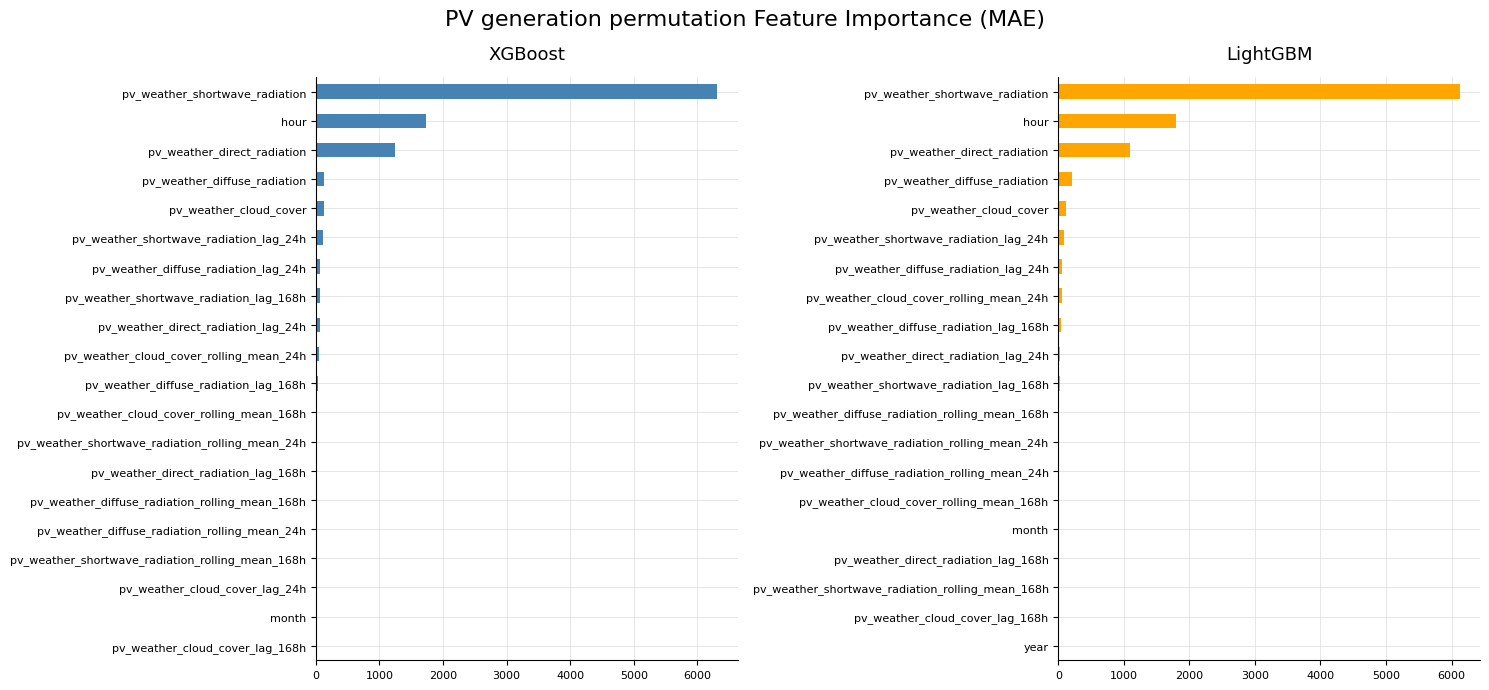

In [35]:
# plot permutation feature importance of three selected models of top 20 features for MAE
from sklearn.inspection import permutation_importance

perm_importance_mae_lgbm = permutation_importance(pv_best_model_lgbm, pv_features_test, pv_target_test, scoring='neg_mean_absolute_error')
perm_importance_mae_xgb = permutation_importance(pv_best_model_xgb, pv_features_test, pv_target_test, scoring='neg_mean_absolute_error')
perm_importances_mae_lgbm = pd.Series(perm_importance_mae_lgbm.importances_mean, index=pv_best_model_lgbm.feature_names_in_).sort_values(ascending=True).tail(20)
perm_importances_mae_xgb = pd.Series(perm_importance_mae_xgb.importances_mean, index=pv_best_model_xgb.feature_names_in_).sort_values(ascending=True).tail(20)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
perm_importances_mae_lgbm.plot.barh(ax=axes[1], color='orange')
axes[1].set_title("LightGBM")
perm_importances_mae_xgb.plot.barh(ax=axes[0], color='steelblue') 
axes[0].set_title("XGBoost")
fig.suptitle("PV generation permutation Feature Importance (MAE)", fontsize=16)
plt.tight_layout()
plt.show()
